In [1]:
# Para instalar Qiskit en tu entorno de Colab, puedes ejecutar esta celda
!pip install qiskit
!pip install pylatexenc
!pip install qiskit-aer

"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


# Sesión 5 Laboratorio de Computación Cuántica 1

## Protocolo de teleportación cuántica

En esta sesión entenderemos el protocolo de teleportación cuántica y como funciona

## Intuición detrás del protocolo

Imagina que Alice tiene un estado cuántico $|\psi\rangle$. Alice se encuentra en su casa en Ciudad de México, y quiere enviarle el estado cuántico a Bob, quien se encuentra en San Jose de Costa Rica. Hoy, Alice puede contactarse con Bob vía telefono celular, llamadas, mensajes y demas a la velocidad de la luz. Pero enviar un estado cuántico es otra cosa completamente diferente. 

- Si Alice mide el estado cuántico, lo rompe
- No hay un "Internet Cuántico" que permita enviar estados cuánticos una y otra vez
- Las componentes del estado cuántico para identificarlas haría falta construir el estado muchas veces

Si contruir el estado muchas veces para medir el sistema no es posible, entonces, ¿Como le envías a Bob el estado cuántico? El protocolo de teleportación cuántica nos da una idea muy buena para hacerlo: Entrelaza 2 qubits usando estados de bell, que sirvan como canal de comunicación entre Alice y Bob

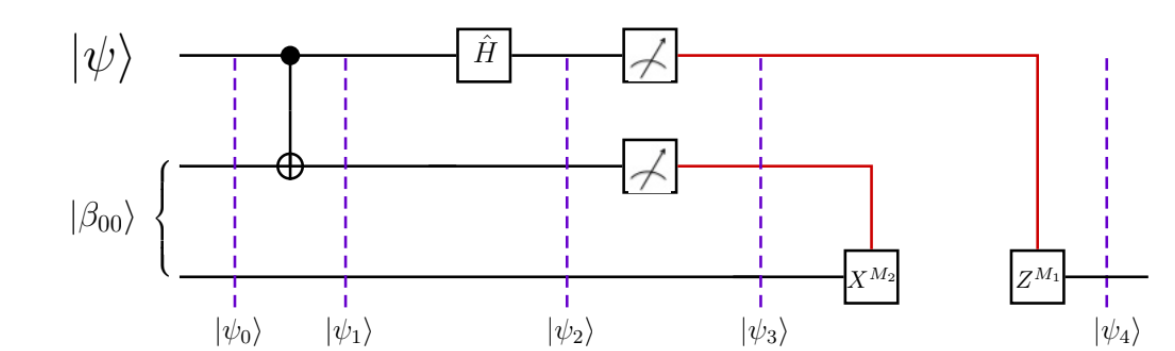

## Circuito del protocolo de teleportación cuántica

En la imagen tenemos el protocolo de teleportación cuántica. Alice va a tener un qubit en estado $|\psi\rangle=\alpha|0\rangle+\beta|1\rangle$ y Alice y bob van a tener ambos un qubit entrelazado, el cual, en su conjunto, van a formar el estado de bell 00, el cual es $\frac{1}{\sqrt{2}}|00\rangle+|11\rangle$.

El estado inicial del sistema $|\psi_0\rangle=|\psi\rangle \otimes |\beta_{00}\rangle=\frac{1}{\sqrt{2}}\left(\alpha|000\rangle+\alpha|011\rangle+\beta|100\rangle+\beta|111\rangle\right)$

Despues de eso, se aplica un CNOT entre el qubit de Alice y el primer qubit de Bob. Esto nos deja el siguiente estado resultante

$|\psi_1\rangle=\frac{1}{\sqrt{2}}\left(\alpha|000\rangle+\alpha|011\rangle+\beta|110\rangle+\beta|101\rangle\right)$

Tras aplicar la compuerta Hadamard y factorizar el estado, recuperamos el siguiente estado:

$|\psi_2\rangle=\frac{1}{2}\left[|00\rangle(\alpha|0\rangle+\beta|1\rangle)+|01\rangle(\alpha|1\rangle+\beta|0\rangle)+|10\rangle(\alpha|0\rangle-\beta|1\rangle)+|11\rangle(\alpha|1\rangle-\beta|0\rangle)\right]$

Fijate en lo interesante de este estado cuántico. Si eres observador, te darás cuenta que podemos desglosar este estado en una combinación lineal de 4 posibles estados. El tercer registro te puede dar algun estado en función de lo que te el segundo y primer registro, y aunque $\alpha$ y $\beta$ esten codificadas, el estado no es exactamente el mismo. Con esto en mente, debemos hacer los ajustes correspondientes al estado al medir los primeros 2 registros y con eso aplicar compuertas X y Z sobre el tercer registro.

Sean $M_1 y M_2$ las mediciones asociadas al primer y segundo registro respectivamente. Si en el segundo registro vemos un 1, aplicamos una compuerta X al tercer registro, y posteriormente, si en el primer registro tenemos un 1, aplicamos una compuerta Z al tercer registro.

## Programación del protocolo de teleportación cuántica en Qiskit

Vamos a ver como podemos fabricar el Protocolo de teleportación cuántica en Qiskit. Para ello, fabricaremos un estado en numpy, lo convertiremos a Statevector en Qiskit, y dicho estado lo teleportaremos utilizando el protocolo.

In [2]:
import numpy as np
from IPython.display import display

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector

In [3]:
# Vamos a crear el estado psi para el protocolo
# Elegimos amplitudes arbitrarias
estado_numpy = np.array([1 + 2j, 3 - 1j], dtype=complex)

# Normalizamos el estado
estado_numpy = estado_numpy / np.linalg.norm(estado_numpy)

print("El estado es", estado_numpy)
print("La norma del estado es ", np.linalg.norm(estado_numpy))

El estado es [0.25819889+0.51639778j 0.77459667-0.25819889j]
La norma del estado es  0.9999999999999999


Una vez hemos creado el estado que vamos a teleportar, vamos a crear el circuito cuántico que nos va a permitir aplicar el protocolo de teleportación cuántica

In [4]:
# Creamos el regitro cuántico sel sistema para poder operar el protocolo
q = QuantumRegister(3, "q")

# Creamos 2 registros clásicos que estaran asociados a las mediciones de los qubits de Alice
m1 = ClassicalRegister(1, "M1")
m2 = ClassicalRegister(1, "M2")

# Fabricamos el circuito
qc = QuantumCircuit(q, m1, m2)

Tras eso, vamos a crear el estado inicial para el protocolo de teleportación cuántica, el estado $|\psi_0\rangle$

In [5]:
qc.initialize(estado_numpy, q[0]) # Iniciamos el estado en el qubit que nosotros hemos trabajado

qc.barrier()

qc.h(q[1])
qc.cx(q[1], q[2]) #Crearemos el estado de Bell entre el segundo y tercer qubit

qc.barrier()


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

Una vez ya hemos creado el estado inicial, ahora si, iniciamos el protocolo de teleportación cuántica

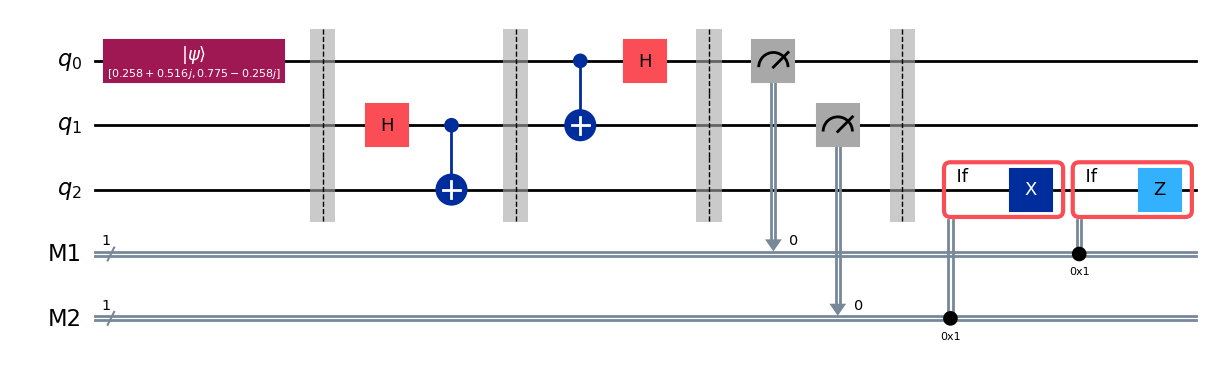

In [6]:
# CNOT entre el Qubit a teleportas y el par de bell de Alice (el segundo qubit)
qc.cx(q[0], q[1])

# Hadamard sobre el estado original
qc.h(q[0])

qc.barrier()

#Alice realiza las mediciones de sus qubits y los guarda en los 2 registros clásico
qc.measure(q[0], m1[0])
qc.measure(q[1], m2[0])

qc.barrier()

# Si M2 = 1, Bob aplica X
with qc.if_test((m2, 1)):   #La función qc.if_test nos permite condicionar la aplicación del protocolo al valor del registro clásico
    qc.x(q[2])

# Si M1 = 1, Bob aplica Z
with qc.if_test((m1, 1)):
    qc.z(q[2])

display(qc.draw("mpl"))

## Verificación del estado inicial

Convertimos el estado que vamos a teleportar en un objeto `Statevector` para poder visualizarlo y utilizarlo en la verificación del protocolo.

In [7]:
psi = Statevector(estado_numpy)

print("Estado inicial como Statevector:")
display(psi.draw("latex"))

Estado inicial como Statevector:


<IPython.core.display.Latex object>

## Resultados posibles y correcciones

Después de medir los qubits de Alice, Bob recibe uno de los siguientes estados. Las correcciones dependen de los resultados `M1` y `M2`.

| M1 M2 | Estado de Bob antes de corregir | Corrección de Bob |
|---|---|---|
| 00 | $\lvert\psi\rangle$ | Ninguna |
| 01 | $X\lvert\psi\rangle$ | $X$ |
| 10 | $Z\lvert\psi\rangle$ | $Z$ |
| 11 | $XZ\lvert\psi\rangle$ | $X$ y $Z$ |

Los resultados `M1` y `M2` son aleatorios, pero después de aplicar la corrección correspondiente el qubit de Bob debe quedar en el estado $|\psi\rangle$.

## Simulación y medición del qubit de Bob

Para observar el resultado final, agregamos un registro clásico para medir el qubit de Bob después de aplicar las correcciones.

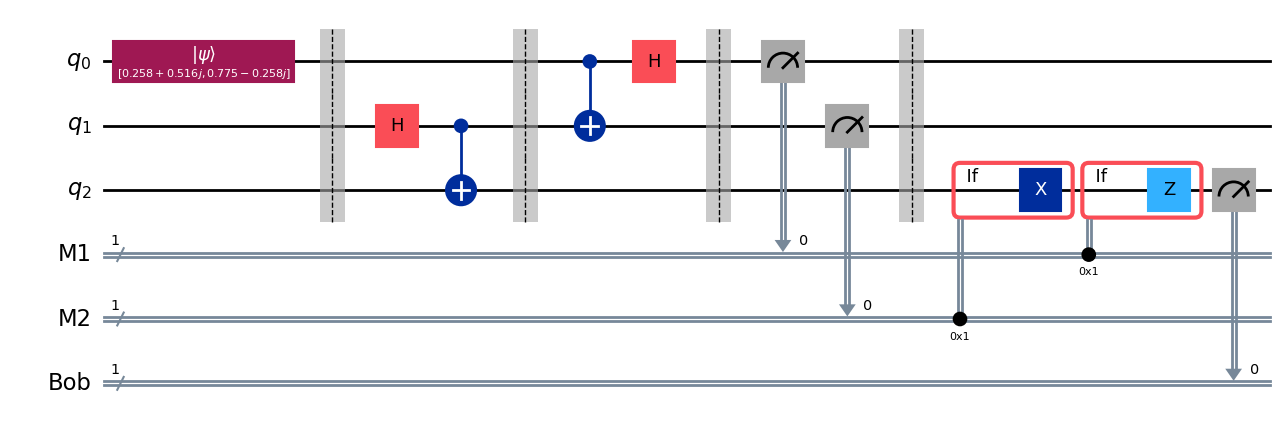

In [8]:
# Registro clásico para medir el qubit de Bob
mbob = ClassicalRegister(1, "Bob")
qc.add_register(mbob)
qc.measure(q[2], mbob[0])

display(qc.draw("mpl"))

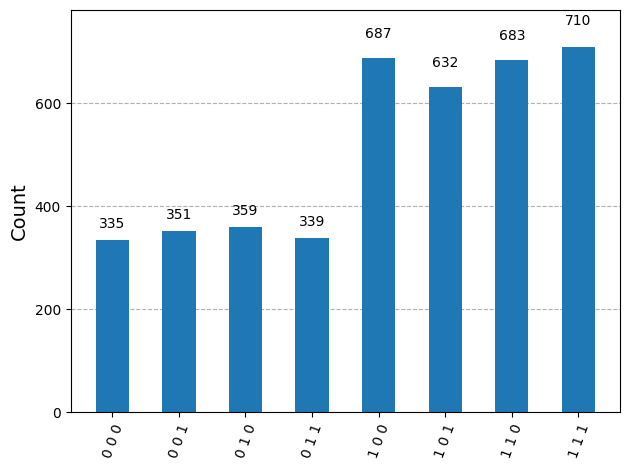

{'1 0 0': 687,
 '0 1 1': 339,
 '1 1 0': 683,
 '1 0 1': 632,
 '0 1 0': 359,
 '0 0 1': 351,
 '1 1 1': 710,
 '0 0 0': 335}

In [9]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

simulador = AerSimulator()
resultado = simulador.run(qc, shots=4096).result()
cuentas = resultado.get_counts(qc)

display(plot_histogram(cuentas))
cuentas

Para el estado elegido al inicio, las probabilidades esperadas al medir el qubit de Bob son:

$P(0)=|\alpha|^2=1/3$ y $P(1)=|\beta|^2=2/3$. Al aumentar el número de `shots`, las frecuencias obtenidas deben aproximarse a estos valores.

## Conclusiones

- La teleportación cuántica transfiere el estado, no la partícula original.
- El estado original se destruye al realizar las mediciones de Alice.
- Alice debe enviar dos bits clásicos a Bob para que pueda elegir las correcciones.
- El protocolo no permite enviar información más rápido que la luz.
- El protocolo no viola el teorema de no clonación: al final no existen dos copias del estado $|\psi\rangle$.

## Ejercicios

1. Repite el protocolo utilizando los estados $|0\rangle$, $|1\rangle$, $|+\rangle$ y $|-\rangle$.
2. ¿Qué ocurre si se elimina la corrección $X$ o la corrección $Z$?
3. Cambia las amplitudes de `estado_numpy` y compara las probabilidades obtenidas para el qubit de Bob.
4. Explica por qué los resultados de las mediciones de Alice son aleatorios, aunque el estado de Bob termine siendo $|\psi\rangle$.